## 1. Project Setup and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
import re
import os
from collections import Counter
from datetime import datetime

warnings.filterwarnings('ignore')

# Install missing libraries
!pip install vaderSentiment
!pip install nltk
!pip install textblob
!pip install wordcloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# ML
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# Wordcloud
from wordcloud import WordCloud

print("All libraries loaded successfully.")
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
All libraries loaded successfully.
Analysis started at: 2026-06-20 05:10:46


In [2]:
df_raw = pd.read_csv('Crumble_reviews.csv')
df = df_raw.copy()

## 2. Missing Data Check

In [3]:
print("\nMissing Value Analysis:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string())


Missing Value Analysis:
                      Missing Count  Missing %
replyContent                    276      100.0
repliedAt                       276      100.0
reviewCreatedVersion             40       14.5
appVersion                       40       14.5


## 3. Review Overview and Ratings

In [4]:
print(f"\nRating Distribution:")
print(df['score'].value_counts().sort_index().to_string())
print(f"\nDate Range: {pd.to_datetime(df['at'], format='%d/%m/%Y %H:%M').min().date()} → {pd.to_datetime(df['at'], format='%d/%m/%Y %H:%M').max().date()}")
print(f"Median Review Length: {df['content'].dropna().str.len().median():.0f} characters")
print(f"Business Reply Rate: {df['replyContent'].notna().mean()*100:.1f}%")


Rating Distribution:
score
1     67
2     22
3     25
4     22
5    140

Date Range: 2023-06-12 → 2026-06-11
Median Review Length: 34 characters
Business Reply Rate: 0.0%


## 4. EDA Dashboard

In [5]:
df['at'] = pd.to_datetime(df['at'], format='%d/%m/%Y %H:%M')
df['month'] = df['at'].dt.to_period('M')
df['month_str'] = df['at'].dt.strftime('%b %Y')
df['quarter'] = df['at'].dt.to_period('Q')
df['review_length'] = df['content'].fillna('').str.len()
df['word_count'] = df['content'].fillna('').str.split().str.len()

In [7]:
# Extracting colors directly from the official Crumble logo
BRAND_PRIMARY = '#0014B3'      # The deep, vibrant Crumble blue
BRAND_SECONDARY = '#1F2937'    # Sleek dark gray for text/contrast
BRAND_ACCENT = '#3B82F6'       # A lighter, complementary digital blue
BRAND_LIGHT = '#F4F6FF'        # An ultra-light blue-gray tint for backgrounds
COLORS_5 = ['#EF4444', '#9CA3AF', '#93C5FD', '#3B82F6', '#0014B3']
PALETTE = sns.color_palette(COLORS_5)
# Apply global Matplotlib configurations
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': BRAND_LIGHT,     # Subtle branded background for the plot area
    'axes.spines.top': False,          # Maximizes data-ink ratio
    'axes.spines.right': False,        # Removes unnecessary right border
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',        # Makes the chart titles pop
    'axes.titlecolor': BRAND_PRIMARY,  # Titles automatically use the brand blue
    'axes.labelsize': 11,
    'axes.labelcolor': BRAND_SECONDARY,     # Axis labels use soft dark gray instead of harsh black
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

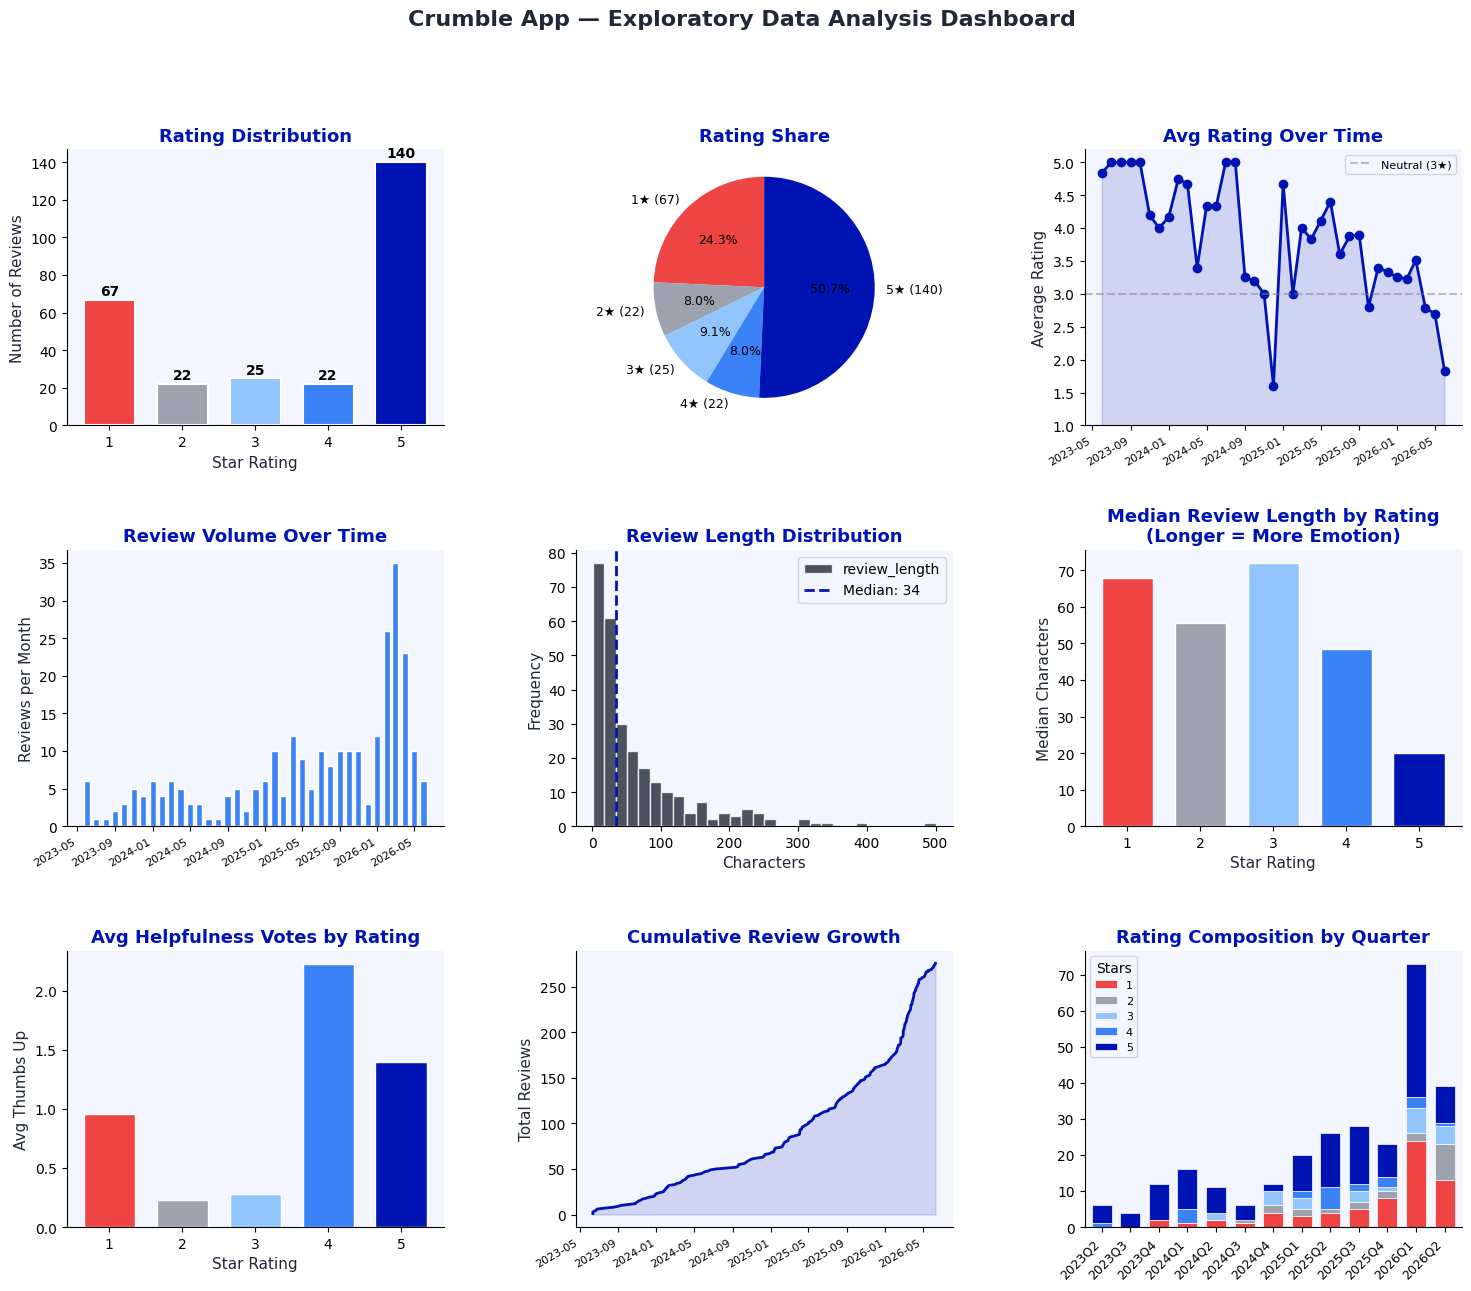

In [8]:
%matplotlib inline
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Crumble App — Exploratory Data Analysis Dashboard',
             fontsize=16, fontweight='bold', color=BRAND_SECONDARY, y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1a. Rating Distribution
ax1 = fig.add_subplot(gs[0, 0])
rating_counts = df['score'].value_counts().sort_index()
bars = ax1.bar(rating_counts.index, rating_counts.values,
               color=[COLORS_5[i] for i in range(5)], edgecolor='white', linewidth=1.5, width=0.7)
for bar, val in zip(bars, rating_counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(val),
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Rating Distribution', fontweight='bold')
ax1.set_xlabel('Star Rating')
ax1.set_ylabel('Number of Reviews')
ax1.set_xticks([1,2,3,4,5])

# 1b. Pie
ax2 = fig.add_subplot(gs[0, 1])
labels = [f'{i}★ ({v})' for i,v in rating_counts.items()]
ax2.pie(rating_counts.values, labels=labels, colors=COLORS_5,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
ax2.set_title('Rating Share', fontweight='bold')

# 1c. Avg rating over time
ax3 = fig.add_subplot(gs[0, 2])
monthly_avg = df.groupby('month')['score'].agg(['mean','count']).reset_index()
monthly_avg['month_dt'] = monthly_avg['month'].dt.to_timestamp()
monthly_avg = monthly_avg.sort_values('month_dt')
ax3.plot(monthly_avg['month_dt'], monthly_avg['mean'],
         color=BRAND_PRIMARY, marker='o', linewidth=2, markersize=6)
ax3.fill_between(monthly_avg['month_dt'], monthly_avg['mean'],
                 alpha=0.15, color=BRAND_PRIMARY)
ax3.axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Neutral (3★)')
ax3.set_title('Avg Rating Over Time', fontweight='bold')
ax3.set_ylabel('Average Rating')
ax3.set_ylim(1,5.2)
ax3.legend(fontsize=8)
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# 1d. Review Volume over time
ax4 = fig.add_subplot(gs[1, 0])
monthly_counts = df.groupby('month').size().reset_index(name='count')
monthly_counts['month_dt'] = monthly_counts['month'].dt.to_timestamp()
monthly_counts = monthly_counts.sort_values('month_dt')
ax4.bar(monthly_counts['month_dt'], monthly_counts['count'],
        color=BRAND_ACCENT, edgecolor='white', width=20)
ax4.set_title('Review Volume Over Time', fontweight='bold')
ax4.set_ylabel('Reviews per Month')
plt.setp(ax4.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# 1e. Review length distribution
ax5 = fig.add_subplot(gs[1, 1])
df['review_length'].clip(upper=500).plot(kind='hist', bins=30,
                                         color=BRAND_SECONDARY, ax=ax5, edgecolor='white', alpha=0.8)
ax5.axvline(df['review_length'].median(), color=BRAND_PRIMARY, linestyle='--', linewidth=2, label=f'Median: {df["review_length"].median():.0f}')
ax5.set_title('Review Length Distribution', fontweight='bold')
ax5.set_xlabel('Characters')
ax5.set_ylabel('Frequency')
ax5.legend()

# 1f. Review length by rating
ax6 = fig.add_subplot(gs[1, 2])
length_by_rating = df.groupby('score')['review_length'].median()
ax6.bar(length_by_rating.index, length_by_rating.values,
        color=[COLORS_5[i] for i in range(5)], edgecolor='white', width=0.7)
ax6.set_title('Median Review Length by Rating\n(Longer = More Emotion)', fontweight='bold')
ax6.set_xlabel('Star Rating')
ax6.set_ylabel('Median Characters')
ax6.set_xticks([1,2,3,4,5])

# 1g. Thumbs up by rating
ax7 = fig.add_subplot(gs[2, 0])
thumbs_by_rating = df.groupby('score')['thumbsUpCount'].mean()
ax7.bar(thumbs_by_rating.index, thumbs_by_rating.values,
        color=[COLORS_5[i] for i in range(5)], edgecolor='white', width=0.7)
ax7.set_title('Avg Helpfulness Votes by Rating', fontweight='bold')
ax7.set_xlabel('Star Rating')
ax7.set_ylabel('Avg Thumbs Up')
ax7.set_xticks([1,2,3,4,5])

# 1h. Cumulative reviews
ax8 = fig.add_subplot(gs[2, 1])
df_sorted = df.sort_values('at')
df_sorted['cumulative'] = range(1, len(df_sorted)+1)
ax8.plot(df_sorted['at'], df_sorted['cumulative'], color=BRAND_PRIMARY, linewidth=2)
ax8.fill_between(df_sorted['at'], df_sorted['cumulative'], alpha=0.15, color=BRAND_PRIMARY)
ax8.set_title('Cumulative Review Growth', fontweight='bold')
ax8.set_ylabel('Total Reviews')
plt.setp(ax8.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# 1i. Rating stacked by month
ax9 = fig.add_subplot(gs[2, 2])
# Grouping by 'quarter' and sorting
pivot_quarter = df.groupby(['quarter', 'score']).size().unstack(fill_value=0)
pivot_quarter = pivot_quarter.sort_index()

# Convert the index to clean string labels (e.g., '2025-Q1')
pivot_quarter.index = pivot_quarter.index.astype(str)

# Plotting with a slightly wider bar width to give breathing room
pivot_quarter.plot(kind='bar', stacked=True, ax=ax9, color=COLORS_5, legend=True,
                   edgecolor='white', linewidth=0.5, width=0.7)

ax9.set_title('Rating Composition by Quarter', fontweight='bold')
ax9.set_xlabel('')

# Clean up the legend position so it doesn't block bars
ax9.legend(title='Stars', loc='upper left', fontsize=8)

# FIX: Rotate labels by 45 degrees and align them to the right edge of the ticks
plt.setp(ax9.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [9]:
# data insight summaries
avg_rating = df['score'].mean()
pct_positive = (df['score']>=4).mean()*100
pct_negative = (df['score']<=2).mean()*100
print(f"\nEDA Key Findings:")
print(f"  • Average Rating:       {avg_rating:.2f} / 5.0")
print(f"  • Positive (4-5):       {pct_positive:.1f}%")
print(f"  • Negative (1-2):       {pct_negative:.1f}%")
print(f"  • Neutral (3):          {(df['score']==3).mean()*100:.1f}%")
print(f"  • Business Reply Rate:  {df['replyContent'].notna().mean()*100:.1f}%")


EDA Key Findings:
  • Average Rating:       3.53 / 5.0
  • Positive (4-5):       58.7%
  • Negative (1-2):       32.2%
  • Neutral (3):          9.1%
  • Business Reply Rate:  0.0%


## 5. Categorical Business Insights

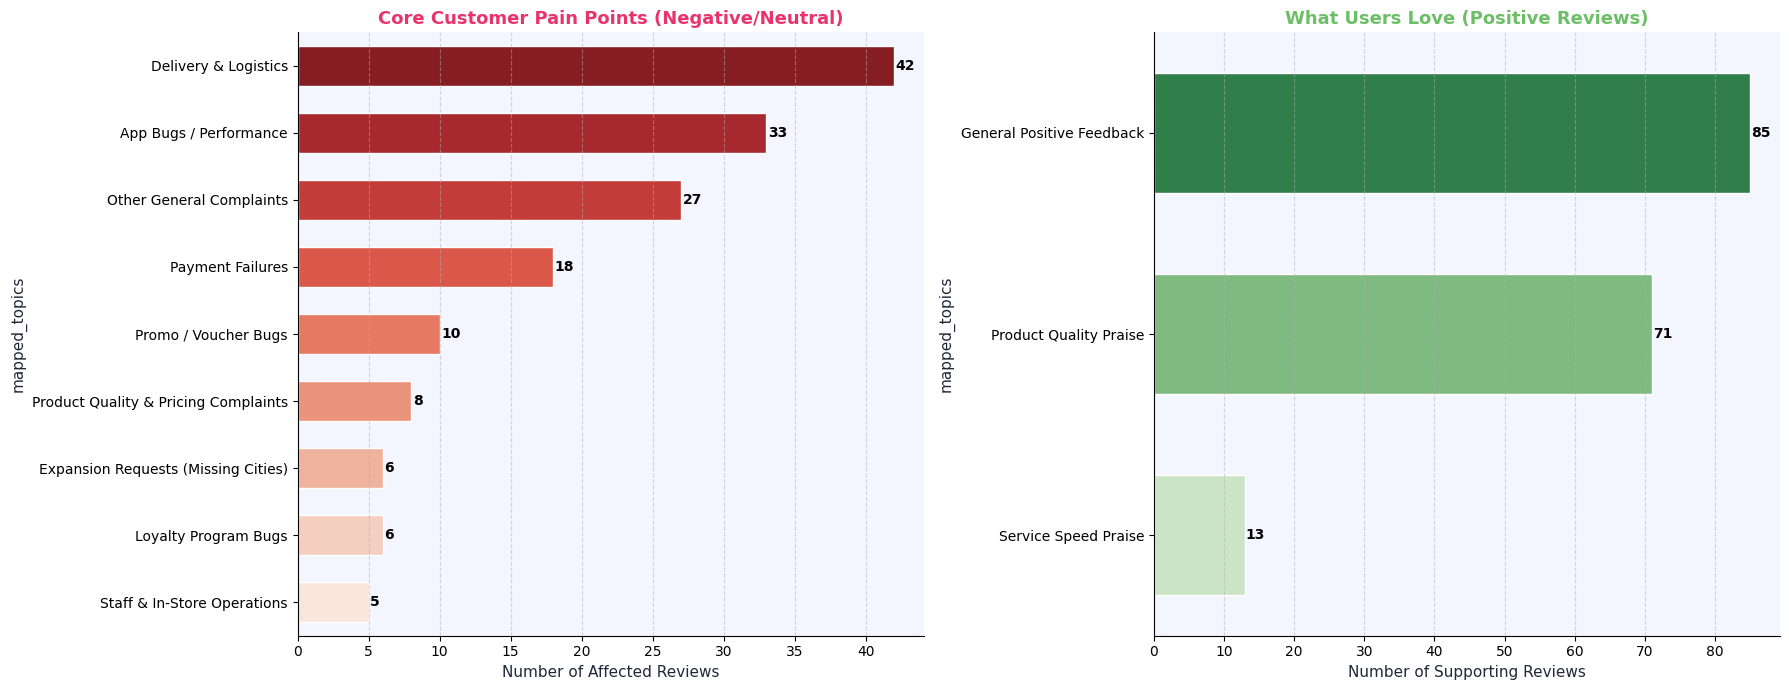

In [13]:

def extract_business_topics(row):
    text = str(row['content']).lower()
    sentiment = row['sentiment_bucket']
    topics = []

    if sentiment in ['NEGATIVE', 'NEUTRAL']:

        # 1. City / Region Availability & Expansion Requests
        if any(w in text for w in ['karachi', 'gujranwala', 'india', 'uk', 'nationwide', 'not available in rawalpindi', 'delivery in lahore']):
            topics.append('Expansion Requests (Missing Cities)')

        # 2. Specific Feature: Loyalty Points / Wallet
        if any(w in text for w in ['point', 'loyality', 'points feature', '188 points']):
            topics.append('Loyalty Program Bugs')

        # 3. Payment Gateway Failures (Strictly financial actions)
        if any(w in text for w in ['payment', 'card', 'debit', 'credit', 'paisa', 'money', 'bank', 'checkout', 'transaction', 'payed']):
            topics.append('Payment Failures')

        # 4. App Bugs & UI Performance (Strictly Technical / System Failures)
        if any(w in text for w in ['slow', 'error', 'bug', 'crash', 'hang', 'stuck', 'loading', 'otp', 'login', 'glitchy', 'website', 'sign up', 'register', 'open once', 'update loop', 'asking for an update', 'not open']):
            # Exclude purely geographic complaints matching "glitchy app" or "slow" to reduce duplication
            if not any(g in text for g in ['karachi', 'gujranwala', 'dha phase 7', 'missing for delivery', 'model town']):
                topics.append('App Bugs / Performance')

        # 5. Delivery & Logistics (Focus purely on physical execution: time, riders, temperature, missing items)
        if 'otp' not in text and any(w in text for w in ['delivery', 'rider', 'late', 'time', '30 minutes', 'delayed', 'location', 'map', 'address', 'missing item', 'cold food', 'incorrect food', 'delivered 2', 'waiting for', 'hour', 'hours']):
            # Filter out pure city blocks that belong in Expansion Requests
            if not any(e in text for e in ['karachi', 'india', 'uk']):
                topics.append('Delivery & Logistics')

        # 6. Promo & Discount Issues (Protected phrases to avoid "available" cross-contamination)
        if any(w in text for w in ['promo code', 'promocode', 'discount', 'coupon', 'voucher', '10% off', 'percent off', 'promo discount']):
            topics.append('Promo / Voucher Bugs')

        # 7. Product Quality Complaints (Kitchen Specific issues)
        if any(w in text for w in ['sweet', 'horrendous taste', 'eww', 'bakwas', 'ice cube', 'sugar', 'taste', 'undercooked', 'burnt', 'over priced', 'expensive', 'overrated', 'hike up']):
            # Filter out simple phrases like "bad app" or "worst app" that belong in performance
            if not any(a in text for a in ['worst app', 'bad application']):
                topics.append('Product Quality & Pricing Complaints')

        # 8. Staff Behavior & In-Store Operations
        if any(w in text for w in ['rude', 'behaviour', 'staff', 'management', 'behavior', 'shop ke bahir', 'counter', 'force u', 'take away']):
            topics.append('Staff & In-Store Operations')

        if not topics:
            topics.append('Other General Complaints')

    else:
        # Rules for Positive Reviews
        if any(w in text for w in ['taste', 'delicious', 'sweet', 'cookies', 'yummy', 'flavor', 'best', 'fresh']):
            topics.append('Product Quality Praise')
        if any(w in text for w in ['fast', 'quick', 'smooth', 'easy', 'on time', 'efficient']):
            topics.append('Service Speed Praise')
        if not topics:
            topics.append('General Positive Feedback')

    return topics

# Create 'sentiment_bucket' column based on 'score'
def get_sentiment_bucket(score):
    if score >= 4:
        return 'POSITIVE'
    elif score == 3:
        return 'NEUTRAL'
    else:
        return 'NEGATIVE'

df['sentiment_bucket'] = df['score'].apply(get_sentiment_bucket)

# Apply the refined parsing strategy
df['mapped_topics'] = df.apply(extract_business_topics, axis=1)

# Explode dataset to safely handle multiple classifications
df_exploded = df.explode('mapped_topics')

# Calculate aggregated value counts
complaints = df_exploded[df_exploded['sentiment_bucket'].isin(['NEGATIVE', 'NEUTRAL'])]['mapped_topics'].value_counts()
praises = df_exploded[df_exploded['sentiment_bucket'] == 'POSITIVE']['mapped_topics'].value_counts()

# ---- GENERATE DUAL-PANEL DATA MODEL CHART ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Cleaned Corporate Pain Points
if not complaints.empty:
    sns.barplot(x=complaints.values, y=complaints.index, ax=ax1, palette='Reds_r', edgecolor='white', width=0.6)
    ax1.set_title('Core Customer Pain Points (Negative/Neutral)', fontsize=13, fontweight='bold', color='#E8336D')
    ax1.set_xlabel('Number of Affected Reviews')
    ax1.grid(axis='x', linestyle='--', alpha=0.5)
    for i, v in enumerate(complaints.values):
        ax1.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=10)

# Panel 2: Brand Praise Drivers
if not praises.empty:
    sns.barplot(x=praises.values, y=praises.index, ax=ax2, palette='Greens_r', edgecolor='white', width=0.6)
    ax2.set_title('What Users Love (Positive Reviews)', fontsize=13, fontweight='bold', color='#6DBF67')
    ax2.set_xlabel('Number of Supporting Reviews')
    ax2.grid(axis='x', linestyle='--', alpha=0.5)
    for i, v in enumerate(praises.values):
        ax2.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


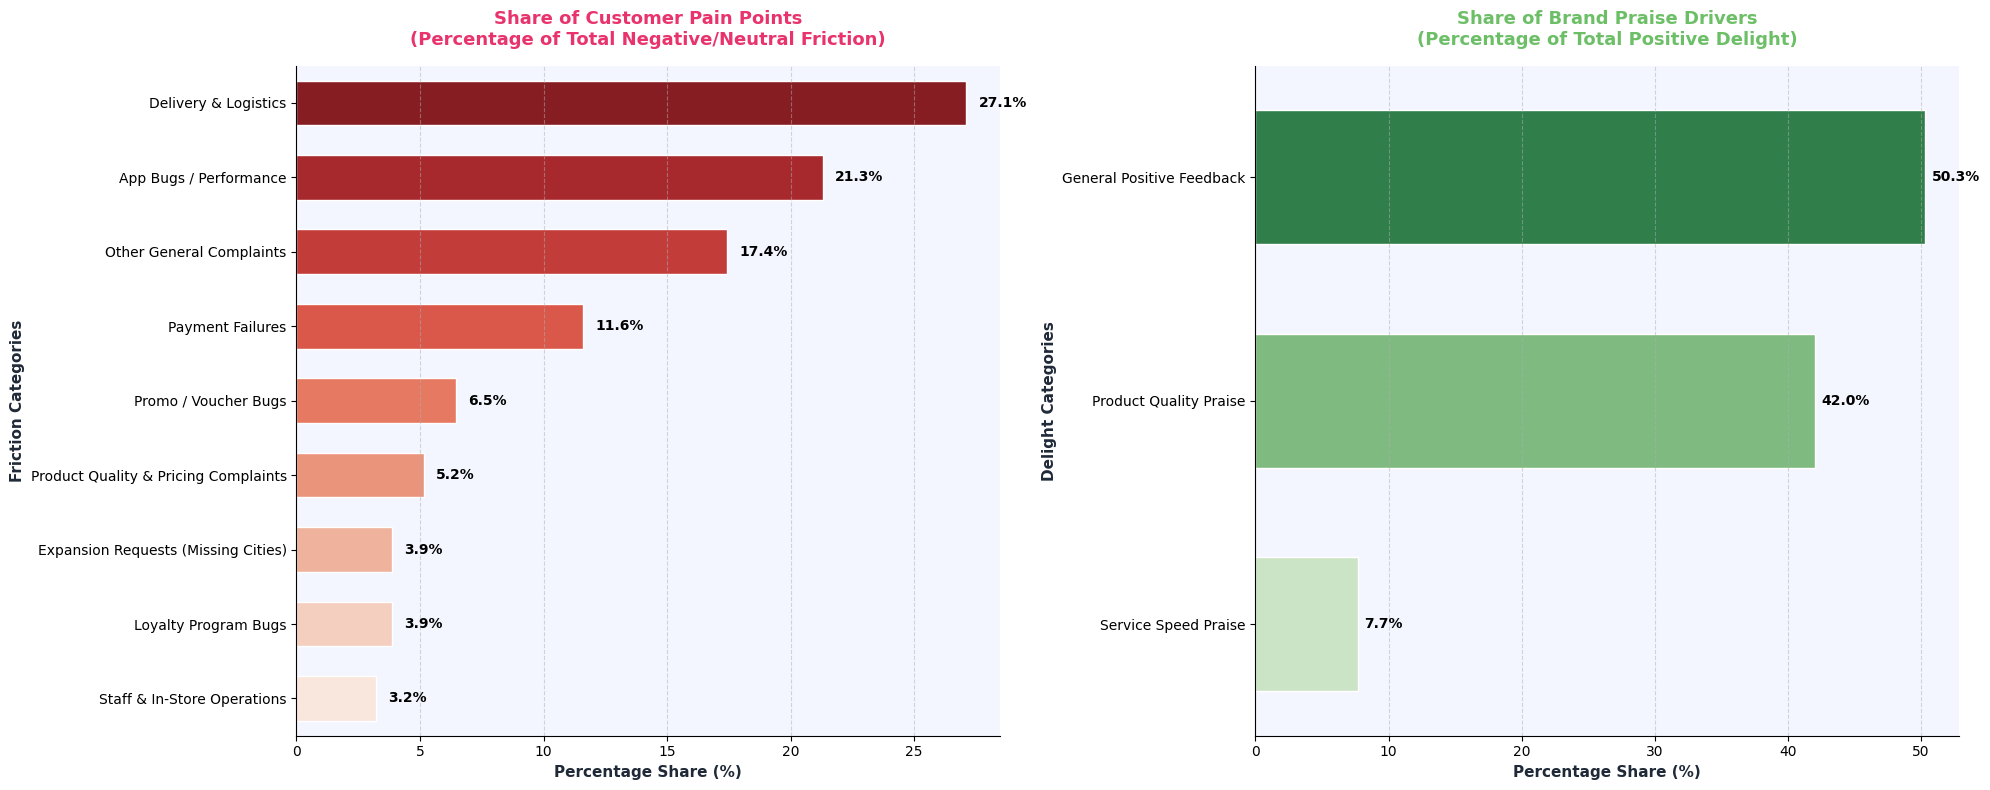

EXECUTIVE TEXT METRICS & INSIGHT NARRATIVES
BREAKDOWN OF PRODUCT & OPERATIONAL FRICTION:
 • Delivery & Logistics                     |  42 reviews |  27.10% of complaints
 • App Bugs / Performance                   |  33 reviews |  21.29% of complaints
 • Other General Complaints                 |  27 reviews |  17.42% of complaints
 • Payment Failures                         |  18 reviews |  11.61% of complaints
 • Promo / Voucher Bugs                     |  10 reviews |   6.45% of complaints
 • Product Quality & Pricing Complaints     |   8 reviews |   5.16% of complaints
 • Expansion Requests (Missing Cities)      |   6 reviews |   3.87% of complaints
 • Loyalty Program Bugs                     |   6 reviews |   3.87% of complaints
 • Staff & In-Store Operations              |   5 reviews |   3.23% of complaints

---------------------------------------------------------------------------

STRATEGIC LEAK: The single largest drag on user satisfaction is 'Delivery & Logistics', 
   acc

In [16]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute Percentages and Totals Safely
total_complaints = complaints.sum()
total_praises = praises.sum()

# 2. Build Percentage DataFrames
if not complaints.empty:
    df_complaints_pct = pd.DataFrame({
        'Volume': complaints.values,
        'Share (%)': (complaints.values / total_complaints * 100).round(2)
    }, index=complaints.index).reset_index()
else:
    df_complaints_pct = pd.DataFrame()

if not praises.empty:
    df_praises_pct = pd.DataFrame({
        'Volume': praises.values,
        'Share (%)': (praises.values / total_praises * 100).round(2)
    }, index=praises.index).reset_index()
else:
    df_praises_pct = pd.DataFrame()

# GENERATE DUAL-PANEL EXECUTIVE PERCENTAGE CHART

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Panel 1: Percentage Share of Customer Pain Points
if not df_complaints_pct.empty:
    sns.barplot(
        x='Share (%)',
        y='mapped_topics',
        data=df_complaints_pct,
        ax=ax1,
        palette='Reds_r',
        edgecolor='white',
        width=0.6
    )
    ax1.set_title('Share of Customer Pain Points\n(Percentage of Total Negative/Neutral Friction)', fontsize=13, fontweight='bold', color='#E8336D', pad=15)
    ax1.set_xlabel('Percentage Share (%)', fontweight='bold')
    ax1.set_ylabel('Friction Categories', fontweight='bold')
    ax1.grid(axis='x', linestyle='--', alpha=0.5)

    # Add percentage labels directly to the bars
    for i, row in df_complaints_pct.iterrows():
        ax1.text(row['Share (%)'] + 0.5, i, f"{row['Share (%)']:.1f}%", va='center', fontweight='bold', fontsize=10)

# Panel 2: Percentage Share of Brand Praise Drivers
if not df_praises_pct.empty:
    sns.barplot(
        x='Share (%)',
        y='mapped_topics',
        data=df_praises_pct,
        ax=ax2,
        palette='Greens_r',
        edgecolor='white',
        width=0.6
    )
    ax2.set_title('Share of Brand Praise Drivers\n(Percentage of Total Positive Delight)', fontsize=13, fontweight='bold', color='#6DBF67', pad=15)
    ax2.set_xlabel('Percentage Share (%)', fontweight='bold')
    ax2.set_ylabel('Delight Categories', fontweight='bold')
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

    # Add percentage labels directly to the bars
    for i, row in df_praises_pct.iterrows():
        ax2.text(row['Share (%)'] + 0.5, i, f"{row['Share (%)']:.1f}%", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# AUTOMATED NARRATIVES GENERATION

print("EXECUTIVE TEXT METRICS & INSIGHT NARRATIVES")

if not df_complaints_pct.empty:
    print("BREAKDOWN OF PRODUCT & OPERATIONAL FRICTION:")
    for i, row in df_complaints_pct.iterrows():
        print(f" • {row['mapped_topics']:<40} | {int(row['Volume']):>3} reviews | {row['Share (%)']:>6.2f}% of complaints")

    print("\n" + "-"*75 + "\n")
    top_complaint = df_complaints_pct.iloc[0]['mapped_topics']
    top_complaint_pct = df_complaints_pct.iloc[0]['Share (%)']
    print(f"STRATEGIC LEAK: The single largest drag on user satisfaction is '{top_complaint}', \n"
          f"   accounting for {top_complaint_pct}% of ALL negative feedback recorded. Fixing this is priority #1.")

if not df_praises_pct.empty:
    print("\n BREAKDOWN OF MARKET ADVOCACY & PRAISE DRIVERS:")
    for i, row in df_praises_pct.iterrows():
        print(f" • {row['mapped_topics']:<40} | {int(row['Volume']):>3} reviews | {row['Share (%)']:>6.2f}% of praises")

    print("\n" + "-"*75 + "\n")
    top_praise = df_praises_pct.iloc[0]['mapped_topics']
    top_praise_pct = df_praises_pct.iloc[0]['Share (%)']
    print(f"BRAND EQUITY: Our primary value driver is '{top_praise}', \n"
          f"   fueling {top_praise_pct}% of our total brand advocacy. This must lead our marketing copy.")

## 6. Word Cloud Visualization

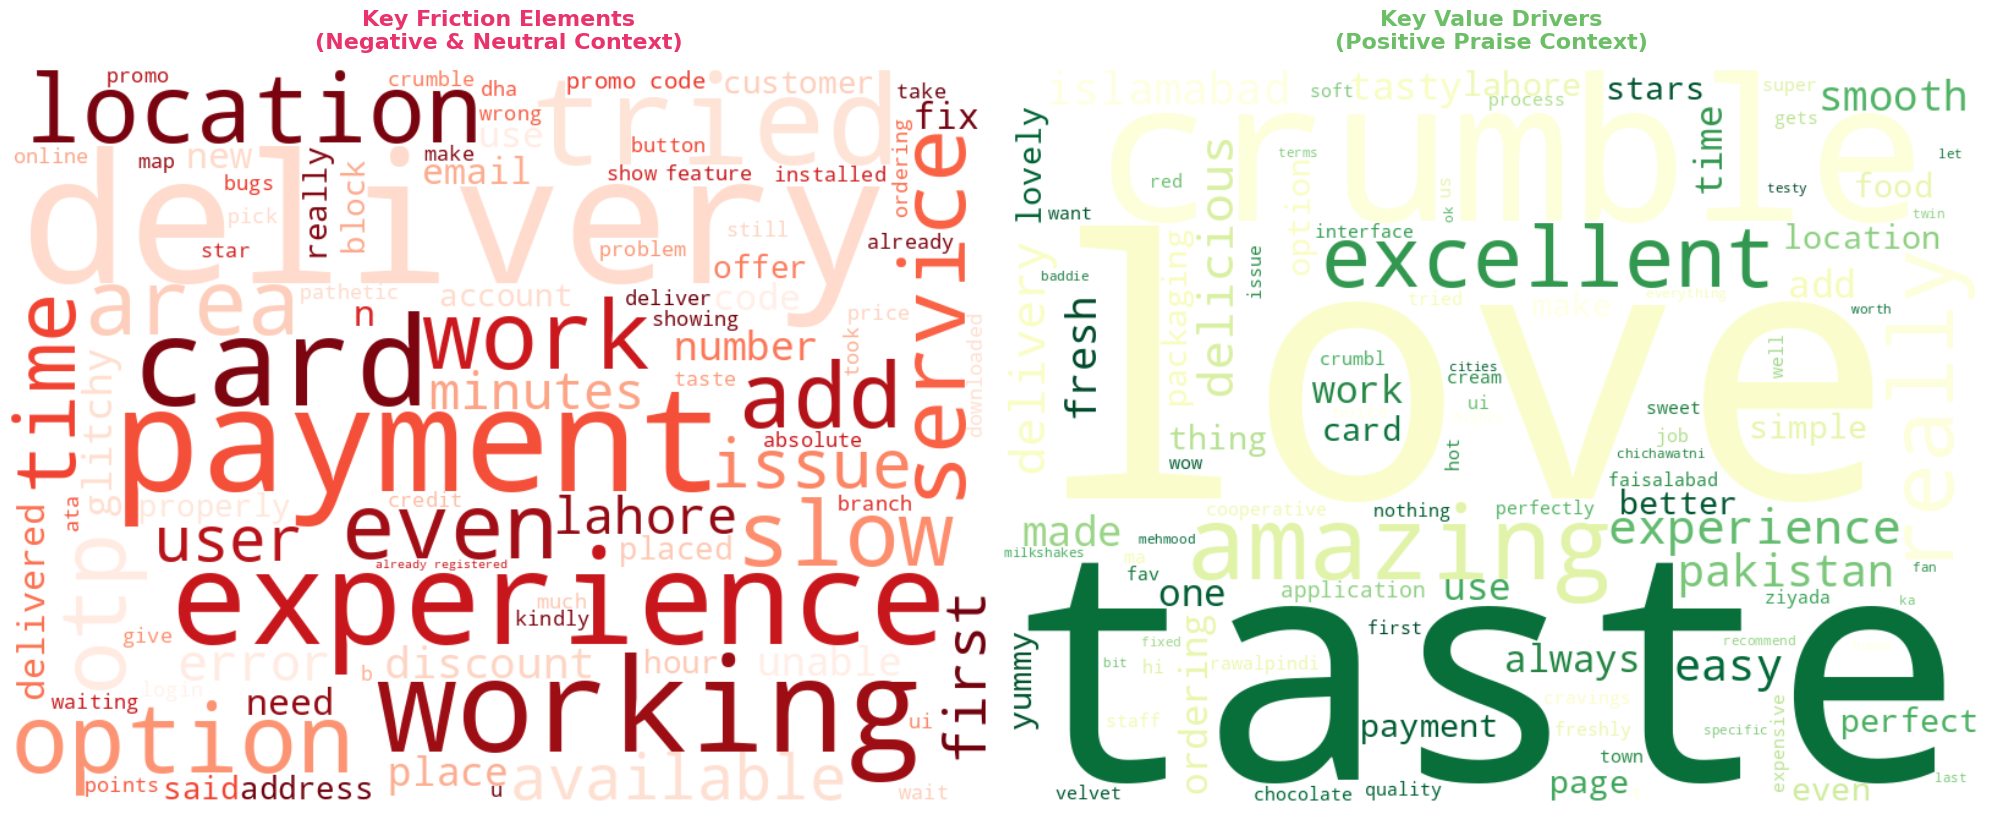

In [20]:

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Compile localized and custom domain stop words to filter out noise
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'app', 'cookies', 'cookie', 'order', 'ordered', 'now', 'will',
    'please', 'good', 'bad', 'worst', 'best', 'great', 'nice', 'awesome'
])
# Note: Removing 'app' and 'cookies' forces the visualization to surface
# the underlying *reasons* (like 'payment', 'otp', 'taste') instead of generic words.

# 2. Extract and join raw text based on structured sentiment segmentation
complaint_text = " ".join(df[df['sentiment_bucket'].isin(['NEGATIVE', 'NEUTRAL'])]['content'].astype(str).str.lower())
praise_text = " ".join(df[df['sentiment_bucket'] == 'POSITIVE']['content'].astype(str).str.lower())

# 3. Initialize the Dual-Panel Layout
fig, (ax_cloud1, ax_cloud2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='white')

# Panel 1: Customer Pain Points Word Cloud (Reds/Dark Tones)
if complaint_text.strip():
    complaint_wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        colormap='Reds_r',      # Professional gradient for issues
        stopwords=custom_stopwords,
        min_font_size=10,
        max_words=100,
        collocations=True       # Keeps key phrases like 'otp code' or 'promo code' connected
    ).generate(complaint_text)

    ax_cloud1.imshow(complaint_wordcloud, interpolation='bilinear')
    ax_cloud1.set_title('Key Friction Elements\n(Negative & Neutral Context)', fontsize=16, fontweight='bold', color='#E8336D', pad=15)
    ax_cloud1.axis('off')
else:
    ax_cloud1.text(0.5, 0.5, 'No negative data available', ha='center', va='center', fontsize=14)
    ax_cloud1.axis('off')

# Panel 2: Brand Drivers Word Cloud (Greens/Fresh Tones)
if praise_text.strip():
    praise_wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        colormap='YlGn_r',     # Warm green gradient for brand delight
        stopwords=custom_stopwords,
        min_font_size=10,
        max_words=100,
        collocations=True       # Keeps key phrases like 'fast delivery' connected
    ).generate(praise_text)

    ax_cloud2.imshow(praise_wordcloud, interpolation='bilinear')
    ax_cloud2.set_title('Key Value Drivers\n(Positive Praise Context)', fontsize=16, fontweight='bold', color='#6DBF67', pad=15)
    ax_cloud2.axis('off')
else:
    ax_cloud2.text(0.5, 0.5, 'No positive data available', ha='center', va='center', fontsize=14)
    ax_cloud2.axis('off')

plt.tight_layout()
plt.show()